In [4]:
from importlib import reload
import MLPModel, LinearModel 
import Model_Training
import numpy as np

reload(MLPModel)
reload(LinearModel)
reload(Model_Training)

import torch
# seed = 42
# torch.manual_seed(seed)


In [ ]:


ticker = "AAPL"
start = '2019-01-01'    # start date
end  = '2026-01-01'     # end date
interval = '1d'         # interval
train_ratio = 0.75
no_epoches = 100_000
lr = 0.0001
tx_fees_bpts = 10
threshold = 0.001

weight_decay = 5e-3

max_lags = 32

modelMLP = MLPModel.MLP # multiplayer perception 

Model = Model_Training.model_training(model = modelMLP(max_lags),
                              tick = ticker,
                              start = start,
                              end = end ,
                              interval = interval,
                              train_ratio = train_ratio,
                              max_lags = max_lags,
                              no_epochs=no_epoches,
                              lr = lr,
                              rtol = 1e-5,
                              trade_signal = "threshold",
                              threshold=threshold,
                              transaction_cost_bpts= tx_fees_bpts,
                              verbose = True,
                              weight_decay= weight_decay)

modelLinear = LinearModel.LinearModel # Linear Model equivalent to AR tine series

ModelLin = Model_Training.model_training(model = modelLinear(max_lags),
                              tick = ticker,
                              start = start,
                              end = end ,
                              interval = interval,
                              train_ratio = train_ratio,
                              max_lags = max_lags,
                              no_epochs=no_epoches,
                              lr = lr,
                              rtol = 1e-5 ,
                              trade_signal = "threshold",
                              threshold=threshold,
                              transaction_cost_bpts= tx_fees_bpts,
                              verbose = True,
                              weight_decay= weight_decay)



[*********************100%***********************]  1 of 1 completed



Training model...
Epoch 0/100000, Loss = 1.004927874
Epoch 500/100000, Loss = 0.972976089
Epoch 1000/100000, Loss = 0.927030325
Epoch 1500/100000, Loss = 0.876952410
Epoch 2000/100000, Loss = 0.827218354
Epoch 2500/100000, Loss = 0.782236159
Epoch 3000/100000, Loss = 0.742416203
Epoch 3500/100000, Loss = 0.706796944
Epoch 4000/100000, Loss = 0.674531817
Epoch 4500/100000, Loss = 0.650819838
Epoch 5000/100000, Loss = 0.629529238
Epoch 5500/100000, Loss = 0.608316183
Epoch 6000/100000, Loss = 0.592717469
Epoch 6500/100000, Loss = 0.576063454
Epoch 7000/100000, Loss = 0.562411606
Epoch 7500/100000, Loss = 0.551374793
Epoch 8000/100000, Loss = 0.542434990
Epoch 8500/100000, Loss = 0.532747805


[*********************100%***********************]  1 of 1 completed

Epoch 9000/100000, Loss = 0.524509549
Relative Tolance Reached at Epoch 9426

 Training Finished! 
 Loss = 0.518698871
Test Loss = 3.694955111

Test Loss = 0.006099821 
Train Loss = 0.000856276

Training model...
Epoch 0/100000, Loss = 1.308554292
Epoch 500/100000, Loss = 1.112433672


Epoch 1000/100000, Loss = 1.020436883
Epoch 1500/100000, Loss = 0.978312969
Epoch 2000/100000, Loss = 0.960534453
Relative Tolance Reached at Epoch 2394

 Training Finished! 
 Loss = 0.954710960
Test Loss = 2.760934114

Test Loss = 0.004557891 
Train Loss = 0.001576070



Test Loss = 0.006099821 
Train Loss = 0.000856276

Test Loss = 0.004557891 
Train Loss = 0.001576070


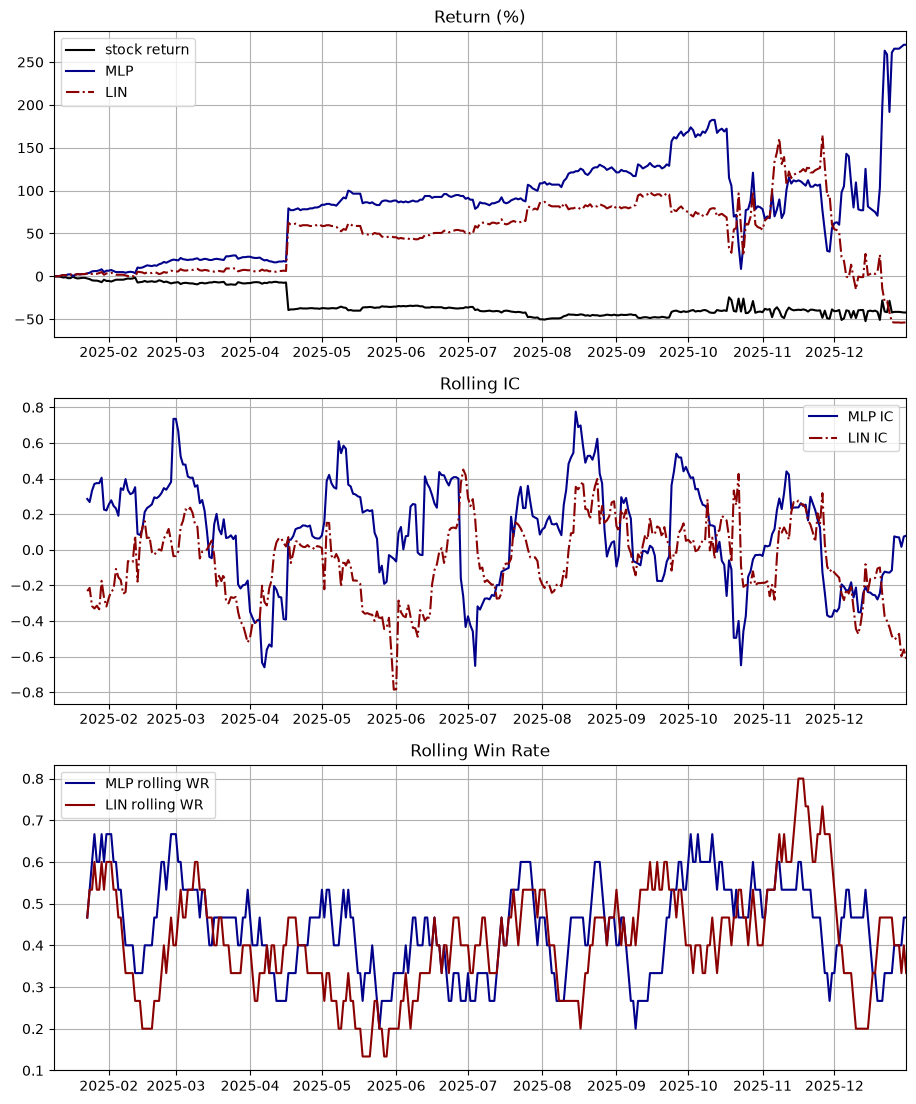

In [11]:
# Plot the Model return, rolling IC, and rolling win rate 
fx_fees_bpts = 0
threshold = 0.0000#0.0000001

window = Model.rolling_window
Model.get_MR_results()
MR_df = Model.MR_df
MR_cum_return = np.expm1(MR_df["trade_log_return_cum"]) * 100



import matplotlib.pyplot as plt
fig, (ax1,ax2,ax3) = plt.subplots(3,1, figsize = (11, 13.5))

Model.get_trade_results(trade_signal="threshold",
                        threshold=threshold, 
                        transaction_fees_bpts= fx_fees_bpts,
                        window = window  )

ModelLin.get_trade_results(trade_signal="threshold",
                           threshold=threshold, 
                           transaction_fees_bpts= fx_fees_bpts, 
                           window = window)

df_MLP = Model.trade_results
df_LIN = ModelLin.trade_results

dates = Model.date_test
return_MLP = np.expm1(df_MLP["trade_log_return_cum"]) * 100
return_stock = np.expm1(Model.T_test.squeeze().numpy().cumsum()) * 100
return_LIN = np.expm1(df_LIN["trade_log_return_cum"]) * 100

# ax1.plot(dates,MR_cum_return,c='green',label='Mean Reversion',ls='dotted')


ax1.plot(dates, return_stock, c='black',label="stock return")
ax1.plot(dates, return_MLP, c='darkblue',label='MLP')
ax1.plot(dates, return_LIN, c='darkred',label='LIN',ls='-.')

ax1.grid()

ax1.set_title("Return (%)")
ax1.legend()


# Plot rolling IC

df = Model.trade_results

win_idx = window//2 
Model.get_model_performance(df)
rolling_ic_MLP = df["rolling_IC"].dropna()

rolling_WR_MLP = df["is_won"].rolling(window = window, min_periods=window).mean().dropna()
df = ModelLin.trade_results
ModelLin.get_model_performance(df)
rolling_ic_LIN = df["rolling_IC"].dropna()
rolling_WR_LIN = df["is_won"].rolling(window = window, min_periods=window).mean().dropna()

ax2.plot(Model.date_test[window-1:], rolling_ic_MLP, c='darkblue', label='MLP IC')
ax2.plot(Model.date_test[window-1:], rolling_ic_LIN, c='darkred', label='LIN IC',ls='-.')
ax2.grid()
ax2.set_title("Rolling IC")
ax2.legend()


# Rolling winrate 
# rolling_WR = df["is_won"].rolling(window = window, min_periods=window).mean()

ax3.set_title("Rolling Win Rate")

ax3.plot(dates[window-1:], rolling_WR_MLP, c='darkblue',label='MLP rolling WR')
ax3.plot(dates[window-1:], rolling_WR_LIN, c='darkred',label='LIN rolling WR')
ax3.legend()
ax3.grid()

for ax in (ax1,ax2,ax3):
    ax.set_xlim(Model.date_test[0], Model.date_test[-1])



# Model.date_test

In [7]:
df["is_won"].mean()

np.float64(0.4061624649859944)

In [8]:
window

15

Overall IC: -0.013708956224487878
Mean rolling IC: 0.09648066235308551
Positive-window fraction: 0.6472303206997084
Minimum: -0.6603178590058217
Maximum: 0.7754891484326252
Win_Rate: 0    0.442577
Name: win_rate, dtype: float64

Overall IC: -0.20944913770001683
Mean rolling IC: -0.0734788298881861
Positive-window fraction: 0.40816326530612246
Minimum: -0.7857264225169774
Maximum: 0.45022502385766044
Win_Rate: 0    0.406162
Name: win_rate, dtype: float64


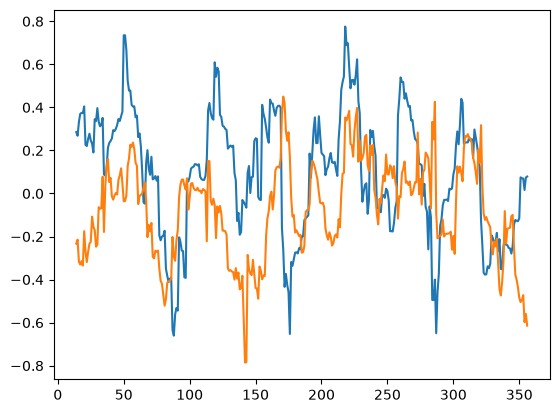

In [9]:

df = Model.trade_results
Model.get_model_performance(df)

rolling_ic = df["rolling_IC"].dropna()
df["rolling_IC"].plot(x=Model.date_test)

print("Overall IC:", df["T_hat"].corr(df["T_test"]))
print("Mean rolling IC:", rolling_ic.mean())
print("Positive-window fraction:", (rolling_ic > 0).mean())
print("Minimum:", rolling_ic.min())
print("Maximum:", rolling_ic.max())
print("Win_Rate:", Model.performance_df["win_rate"])



df = ModelLin.trade_results
ModelLin.get_model_performance(df)

rolling_ic = df["rolling_IC"].dropna()
df["rolling_IC"].plot(x=Model.date_test)

print("\nOverall IC:", df["T_hat"].corr(df["T_test"]))
print("Mean rolling IC:", rolling_ic.mean())
print("Positive-window fraction:", (rolling_ic > 0).mean())
print("Minimum:", rolling_ic.min())
print("Maximum:", rolling_ic.max())
print("Win_Rate:", ModelLin.performance_df["win_rate"])